# Phase-2: Training-Only Energy Optimization


### Global Configuration & Imports

In [1]:
import os
import json
import time
import random
import threading
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

# Reproducibility 
GLOBAL_SEED = 0

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(GLOBAL_SEED)


# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert DEVICE.type == "cuda", "GPU not detected — Phase-2 requires a GPU"

# Locked Hyperparameters
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

LAMBDA_VALUES = [0.0, 1e-5, 1e-4, 1e-3]
SEEDS = [0]  

# -------------------------------
# Directory Structure
# -------------------------------
BASE_DIR = Path("./phase2")
BASE_DIR.mkdir(parents=True, exist_ok=True)

def get_run_dir(model_name, lambda_value, seed):
    return (
        BASE_DIR
        / model_name
        / f"lambda{lambda_value}"
        / f"seed{seed}"
    )

# -------------------------------
# Dataset (CIFAR-10)
# -------------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
])

train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print("Phase-2 global configuration loaded successfully.")
print("CUDA:", torch.version.cuda)
print("cuDNN:", torch.backends.cudnn.version())


100%|██████████| 170M/170M [00:04<00:00, 39.0MB/s] 


Phase-2 global configuration loaded successfully.
CUDA: 12.6
cuDNN: 91002


### Energy Logger (NVML): Stateless GPU Power Sampling Utilities

In [2]:
import pynvml

pynvml.nvmlInit()
NVML_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)


In [3]:
class EnergyLogger:
    """
    Stateless GPU power logger.
    Samples instantaneous GPU power (Watts).
    """

    def __init__(self, output_csv, interval_sec=0.1):
        self.output_csv = output_csv
        self.interval_sec = interval_sec
        self._stop_event = threading.Event()
        self._thread = None

    def _log_power(self):
        with open(self.output_csv, "w") as f:
            f.write("timestamp,power_watts\n")
            while not self._stop_event.is_set():
                timestamp = time.time()
                power_mw = pynvml.nvmlDeviceGetPowerUsage(NVML_HANDLE)
                power_watts = power_mw / 1000.0
                f.write(f"{timestamp},{power_watts}\n")
                f.flush()
                time.sleep(self.interval_sec)

    def start(self):
        self._stop_event.clear()
        self._thread = threading.Thread(target=self._log_power)
        self._thread.daemon = True
        self._thread.start()

    def stop(self):
        self._stop_event.set()
        if self._thread is not None:
            self._thread.join()


In [4]:
def integrate_energy(csv_path):
    """
    Compute total energy (Joules) from power trace.
    Robust to timestamp jitter and duplicates.
    """
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)

    if data.ndim == 1 or data.shape[0] < 2:
        return 0.0

    timestamps = data[:, 0]
    powers = data[:, 1]  # Watts

    dt = np.diff(timestamps)
    valid = dt > 0

    energy_joules = np.sum(powers[:-1][valid] * dt[valid])
    return energy_joules


### Training-Only Energy Optimization: Single Atomic Training Run

In [5]:
def build_model(model_name):
    """
    Build model architectures for CIFAR-10.
    Phase-invariant across all experiments.
    """
    if model_name == "resnet18":
        model = models.resnet18(num_classes=10)

        # CIFAR-10 specific adjustment
        model.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        model.maxpool = nn.Identity()

    elif model_name == "mobilenetv2":
        model = models.mobilenet_v2(num_classes=10)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(DEVICE)


In [6]:
def evaluate(model):
    """
    Evaluate model accuracy on CIFAR-10 test set.
    Used for early stopping and final reporting.
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            _, preds = outputs.max(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100.0 * correct / total


In [7]:
def run_phase2(model_name, lambda_value, seed=0):
    """
    Phase-2: Training-only energy optimization via fixed training budgets.
    λ controls the fraction of full training performed.
    """

    # -------------------------------
    # Run directory & skip guard
    # -------------------------------
    run_dir = get_run_dir(model_name, lambda_value, seed)
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_path = run_dir / "metrics.json"
    energy_csv = run_dir / "energy.csv"
    model_path = run_dir / "model.pt"

    if metrics_path.exists():
        print(f"[SKIP] {model_name}, λ={lambda_value}, seed={seed}")
        return

    print(f"[RUN] {model_name}, λ={lambda_value}, seed={seed}")
    set_seed(seed)

    # -------------------------------
    # Training budget (LOCKED, A PRIORI)
    # -------------------------------
    if lambda_value == 0.0:
        max_epochs = EPOCHS          # 100%
    elif lambda_value == 1e-5:
        max_epochs = int(0.8 * EPOCHS)  # 80%
    elif lambda_value == 1e-4:
        max_epochs = int(0.5 * EPOCHS)  # 50%
    else:  # lambda_value >= 1e-3
        max_epochs = int(0.25 * EPOCHS) # 25%

    # -------------------------------
    # Model, optimizer, loss
    # -------------------------------
    model = build_model(model_name)

    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[50, 75], gamma=0.1
    )

    # -------------------------------
    # Energy logger
    # -------------------------------
    logger = EnergyLogger(output_csv=energy_csv, interval_sec=0.1)

    # -------------------------------
    # Training loop (budget-limited)
    # -------------------------------
    start_time = time.time()
    logger.start()

    for epoch in range(max_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        scheduler.step()

    logger.stop()
    end_time = time.time()

    # -------------------------------
    # Final evaluation & energy
    # -------------------------------
    accuracy = evaluate(model)
    training_energy = integrate_energy(energy_csv)

    # -------------------------------
    # Save artifacts
    # -------------------------------
    torch.save(model.state_dict(), model_path)

    metrics = {
        "model": model_name,
        "lambda": lambda_value,
        "seed": seed,
        "accuracy": accuracy,
        "training_time_sec": end_time - start_time,
        "training_energy_j": training_energy,
        "training_energy_kj": training_energy / 1000.0,
        "max_epochs": max_epochs
    }

    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    print(
        f"[DONE] {model_name}, λ={lambda_value} | "
        f"Epochs={max_epochs} | "
        f"Acc={accuracy:.2f}% | "
        f"Energy={training_energy/1000:.2f} kJ | "
        f"Time={(end_time-start_time)/60:.1f} min"
    )


In [8]:
run_phase2("resnet18", 0.0, seed=0)


[RUN] resnet18, λ=0.0, seed=0
[DONE] resnet18, λ=0.0 | Epochs=100 | Acc=94.42% | Energy=286.75 kJ | Time=71.1 min


In [9]:
PHASE2_CONFIGS = [
    ("resnet18", 1e-5),
    ("resnet18", 1e-4),
    ("resnet18", 1e-3),
]

for model_name, lambda_value in PHASE2_CONFIGS:
    run_phase2(model_name, lambda_value, seed=0)


[RUN] resnet18, λ=1e-05, seed=0
[DONE] resnet18, λ=1e-05 | Epochs=80 | Acc=94.26% | Energy=229.44 kJ | Time=56.9 min
[RUN] resnet18, λ=0.0001, seed=0
[DONE] resnet18, λ=0.0001 | Epochs=50 | Acc=81.47% | Energy=143.49 kJ | Time=35.6 min
[RUN] resnet18, λ=0.001, seed=0
[DONE] resnet18, λ=0.001 | Epochs=25 | Acc=82.62% | Energy=71.83 kJ | Time=17.8 min


In [11]:
import shutil

shutil.make_archive("phase2", "zip", "phase2")
print("phase2.zip created")


phase2.zip created


In [12]:
run_phase2("mobilenetv2", 0.0, seed=0)
run_phase2("mobilenetv2", 1e-5, seed=0)
run_phase2("mobilenetv2", 1e-4, seed=0)
run_phase2("mobilenetv2", 1e-3, seed=0)


[RUN] mobilenetv2, λ=0.0, seed=0
[DONE] mobilenetv2, λ=0.0 | Epochs=100 | Acc=83.40% | Energy=98.11 kJ | Time=40.6 min
[RUN] mobilenetv2, λ=1e-05, seed=0
[DONE] mobilenetv2, λ=1e-05 | Epochs=80 | Acc=82.92% | Energy=78.67 kJ | Time=32.7 min
[RUN] mobilenetv2, λ=0.0001, seed=0
[DONE] mobilenetv2, λ=0.0001 | Epochs=50 | Acc=64.21% | Energy=49.19 kJ | Time=20.5 min
[RUN] mobilenetv2, λ=0.001, seed=0
[DONE] mobilenetv2, λ=0.001 | Epochs=25 | Acc=62.11% | Energy=24.63 kJ | Time=10.2 min


In [13]:
import csv
import json
from pathlib import Path

summary_path = Path("phase2/summary_phase2.csv")
rows = []

for metrics_file in Path("phase2").rglob("metrics.json"):
    with open(metrics_file) as f:
        m = json.load(f)
        rows.append({
            "model": m["model"],
            "lambda": m["lambda"],
            "seed": m["seed"],
            "epochs": m["max_epochs"],
            "accuracy": m["accuracy"],
            "training_energy_kj": m["training_energy_kj"],
            "training_time_sec": m["training_time_sec"],
        })

rows = sorted(rows, key=lambda x: (x["model"], x["lambda"]))

with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print("Phase-2 summary written to:", summary_path)


Phase-2 summary written to: phase2/summary_phase2.csv


## Phase-2 Pareto Analysis — Training Energy vs Accuracy

This section visualizes the training-only energy–accuracy trade-offs obtained in Phase-2.
Each point corresponds to one training configuration (architecture + training budget).

### Axes
- **x-axis:** Training Energy (kJ)
- **y-axis:** Test Accuracy (%)

Lower energy and higher accuracy are preferred.
Pareto-efficient points illustrate configurations where energy reductions cannot be
achieved without sacrificing accuracy.

Separate Pareto fronts are shown for ResNet-18 and MobileNet-V2 to highlight
architecture-dependent training-energy behavior.


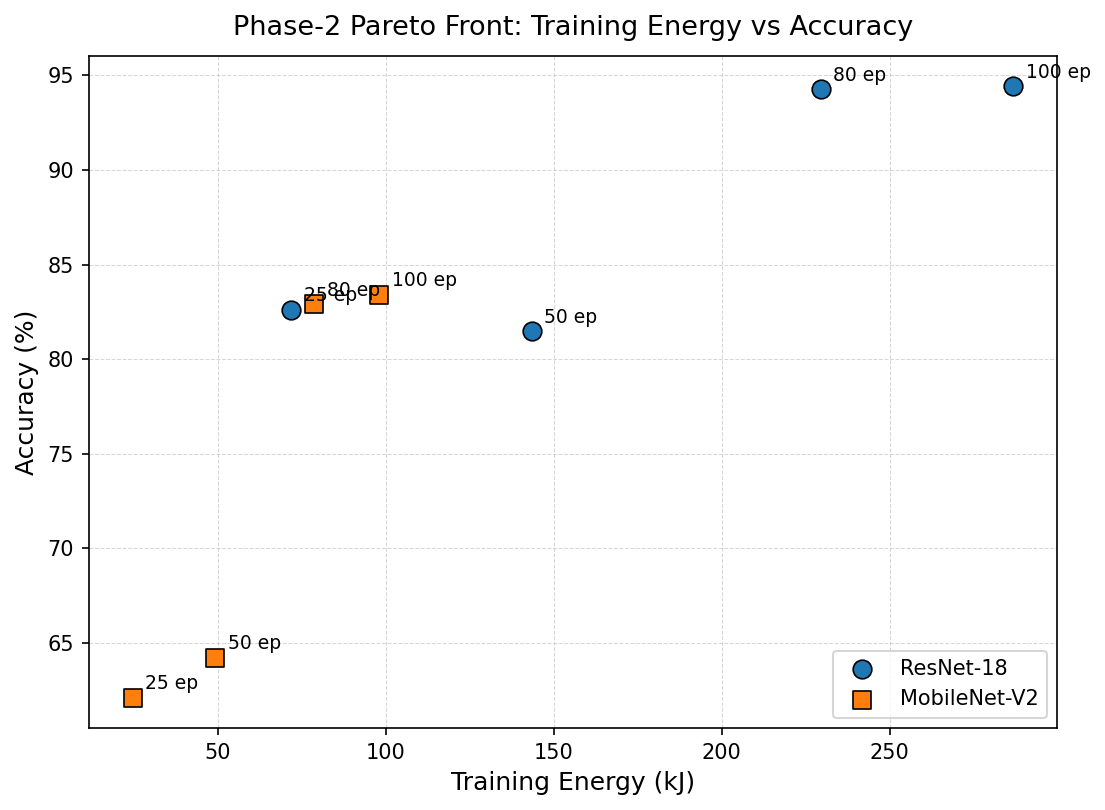

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load summary
df = pd.read_csv("phase2/summary_phase2.csv")

df_resnet = df[df["model"] == "resnet18"]
df_mobilenet = df[df["model"] == "mobilenetv2"]

# -------------------------------
# Camera-ready styling
# -------------------------------
plt.figure(figsize=(7.5, 5.5), dpi=150)

# Scatter plots
plt.scatter(
    df_resnet["training_energy_kj"],
    df_resnet["accuracy"],
    s=80,
    marker="o",
    edgecolors="black",
    linewidths=0.8,
    label="ResNet-18",
    zorder=3
)

plt.scatter(
    df_mobilenet["training_energy_kj"],
    df_mobilenet["accuracy"],
    s=80,
    marker="s",
    edgecolors="black",
    linewidths=0.8,
    label="MobileNet-V2",
    zorder=3
)

# Annotations (epochs)
for _, row in df.iterrows():
    plt.annotate(
        f'{int(row["epochs"])} ep',
        (row["training_energy_kj"], row["accuracy"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9
    )

# Axes labels
plt.xlabel("Training Energy (kJ)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)

# Title
plt.title(
    "Phase-2 Pareto Front: Training Energy vs Accuracy",
    fontsize=13,
    pad=10
)

# Grid (light, unobtrusive)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend
plt.legend(
    frameon=True,
    fontsize=10,
    loc="lower right"
)

# Tight layout for export
plt.tight_layout()

plt.show()


In [16]:
plt.savefig(
    "phase2_pareto_training_energy.pdf",
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

In [17]:
import shutil

shutil.make_archive(
    "phase2_camera_ready",
    "zip",
    "phase2"
)

print("phase2_camera_ready.zip created")


phase2_camera_ready.zip created
